In [12]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated, Literal
from pydantic import BaseModel, Field
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import JsonOutputParser
import json
import operator
import os


In [22]:
# define the state

class QurdState(TypedDict):

    a : int
    b : int
    c : int

    equestion: str
    descrimient: float
    result: str
    

In [23]:
def show_equation(state: QurdState):

    equation = f"{state['a']}x2{state['b']}x{state['c']}"

    return  {'equestion': equation}

def calculate_descriminent(state: QurdState):
    d = state['b']**2 - 4*state['a']*state['c']

    return {'descrimient': d}


def real_roots(state: QurdState):
    root1 = (-state["b"] + state["descrimient"]**0.5)/(2*state["a"])
    root2 = (-state["b"] - state["descrimient"]**0.5)/(2*state["a"])

    result = f'The roots are {root1} and {root2}'

    return {'result': result}

def repeated_roots(state: QurdState):

    root = (-state["b"])/(2*state["a"])

    result = f'Only repeating root is {root}'

    return {'result': result}
    

def no_real_roots(state: QurdState):
    result = f'No real roots'
    return {'result': result}


def check_condition(state:QurdState)-> Literal['real_roots', 'repeated_roots', 'no_real_roots']:
    
    if state['descrimient'] > 0:
        return 'real_roots'
    
    elif state['descrimient'] == 0:
        return 'repeated_roots'
    
    else:
        return 'no_real_roots'


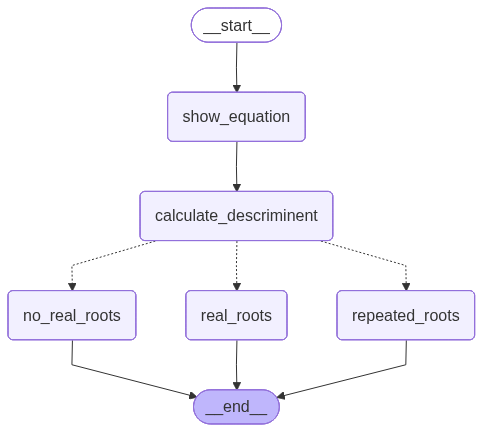

In [24]:
# define the StateGraph

graph = StateGraph(QurdState)

# add node
graph.add_node('show_equation', show_equation)
graph.add_node('calculate_descriminent', calculate_descriminent)
graph.add_node('real_roots', real_roots)
graph.add_node('repeated_roots', repeated_roots)
graph.add_node('no_real_roots', no_real_roots)



# add edge
graph.add_edge(START, 'show_equation')
graph.add_edge('show_equation', 'calculate_descriminent')
graph.add_conditional_edges('calculate_descriminent', check_condition)
graph.add_edge('real_roots', END)
graph.add_edge('repeated_roots', END)
graph.add_edge('no_real_roots', END)
# compile the graph

graph.compile()





In [25]:
# run the graph 
workflow = graph.compile()

initial_state = {'a': 4, 'b': -5, 'c': -2}

final_state = workflow.invoke(initial_state)
final_state

{'a': 4,
 'b': -5,
 'c': -2,
 'equestion': '4x2-5x-2',
 'descrimient': 57,
 'result': 'The roots are 1.5687293044088437 and -0.3187293044088437'}